# 🎵 The Sound of Each Decade — EDA Notebook
## Data Setup, Quality Audit, Cleaning & Decade Labeling

**Datasets used:**
- `data_w_genres.csv` — 160k tracks with an added genres column (main analysis file)
- `data_by_year.csv` — pre-aggregated yearly summaries (used for track count verification)

**What this notebook produces:**
- `spotify_clean.csv` — the shared clean file that can be loaded directly
- A printed data quality report for Slide 3
- Real values for the Slide 3 sample track table
- A documented log of every cleaning decision made

**Notebook structure:**
1. Imports & file paths
2. Load both datasets & first look
3. Data quality audit (nulls, ranges, dtypes)
4. Noise track removal & cleaning decisions
5. Decade column creation & track count check
6. Sample track lookup for Slide 3
7. Save `spotify_clean.csv`
8. Summary report — numbers for next steps

---
> ⚠️ **NOTE** Always load `spotify_clean.csv`, never the raw files. All cleaning decisions are documented in Section 4.

> ⚠️ **NOTE** Change dataset path after mounting your drive to the respective path of data

## 1. Imports & File Paths

In [9]:
import kagglehub
path = kagglehub.dataset_download("yamaerenay/spotify-dataset-1921-2020-160k-tracks")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spotify-dataset-1921-2020-160k-tracks' dataset.
Path to dataset files: /kaggle/input/spotify-dataset-1921-2020-160k-tracks


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plotting defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0A0C10',
    'axes.facecolor':   '#0F1320',
    'axes.edgecolor':   '#1E2A45',
    'axes.labelcolor':  '#6B7A99',
    'xtick.color':      '#6B7A99',
    'ytick.color':      '#6B7A99',
    'text.color':       '#F0F4FF',
    'grid.color':       '#1E2A45',
    'grid.linestyle':   '--',
    'figure.dpi':       120,
})

CYAN   = '#00D4FF'
PURPLE = '#8B5CF6'
AMBER  = '#F59E0B'
GREEN  = '#10B981'
MUTED  = '#6B7A99'

# ── File paths — update these to match where you saved the Kaggle download ────
# If you put both CSVs in the same folder as this notebook, these work as-is.
PATH_TRACKS = '/root/.cache/kagglehub/datasets/yamaerenay/spotify-dataset-1921-2020-160k-tracks/versions/1/data.csv'    # main track-level file with genres column
PATH_BY_YEAR = '/root/.cache/kagglehub/datasets/yamaerenay/spotify-dataset-1921-2020-160k-tracks/versions/1/data_by_year.csv'    # pre-aggregated yearly summary
PATH_OUTPUT  = './spotify_clean.csv'   # ← this is what Persons 2 & 3 will load

print('✅ Imports done.')

✅ Imports done.


---
## 2. Load Both Datasets & First Look

In [11]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw   = pd.read_csv(PATH_TRACKS)
df_year  = pd.read_csv(PATH_BY_YEAR)

print('=' * 60)
print('TRACKS FILE  (data_w_genres.csv)')
print('=' * 60)
print(f'  Rows       : {df_raw.shape[0]:,}')
print(f'  Columns    : {df_raw.shape[1]}')
print(f'  Year range : {df_raw["year"].min()} – {df_raw["year"].max()}')
print()
print('YEAR SUMMARY FILE  (data_by_year.csv)')
print('=' * 60)
print(f'  Rows       : {df_year.shape[0]:,}')
print(f'  Columns    : {df_year.shape[1]}')
print(f'  Year range : {df_year["year"].min()} – {df_year["year"].max()}')

TRACKS FILE  (data_w_genres.csv)
  Rows       : 170,653
  Columns    : 19
  Year range : 1921 – 2020

YEAR SUMMARY FILE  (data_by_year.csv)
  Rows       : 100
  Columns    : 14
  Year range : 1921 – 2020


In [12]:
# ── Schema — every column and its dtype ───────────────────────────────────────
print('\nCOLUMNS IN TRACKS FILE:')
print('-' * 40)
for col in df_raw.columns:
    print(f'  {col:<30} {str(df_raw[col].dtype):<12}')


COLUMNS IN TRACKS FILE:
----------------------------------------
  valence                        float64     
  year                           int64       
  acousticness                   float64     
  artists                        object      
  danceability                   float64     
  duration_ms                    int64       
  energy                         float64     
  explicit                       int64       
  id                             object      
  instrumentalness               float64     
  key                            int64       
  liveness                       float64     
  loudness                       float64     
  mode                           int64       
  name                           object      
  popularity                     int64       
  release_date                   object      
  speechiness                    float64     
  tempo                          float64     


In [13]:
# ── Quick preview of both files ───────────────────────────────────────────────
print('TRACKS — first 3 rows:')
display(df_raw.head(3))

print('\nDATA BY YEAR — first 5 rows:')
display(df_year.head(5))

TRACKS — first 3 rows:


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339



DATA BY YEAR — first 5 rows:


,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.205710,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.240720,-19.275282,0.116655,100.884521,0.535549,0.140845,10
2,1,1923,0.957247,0.577341,177942.362162,0.262406,0.371733,0.227462,-14.129211,0.093949,114.010730,0.625492,5.389189,0
3,1,1924,0.940200,0.549894,191046.707627,0.344347,0.581701,0.235219,-14.231343,0.092089,120.689572,0.663725,0.661017,10
4,1,1925,0.962607,0.573863,184986.924460,0.278594,0.418297,0.237668,-14.146414,0.111918,115.521921,0.621929,2.604317,5


---
## 3. Data Quality Audit
### 3a. Null / Missing Value Report

In [14]:
# ── Null counts and % per column ──────────────────────────────────────────────
null_df = pd.DataFrame({
    'null_count': df_raw.isnull().sum(),
    'null_pct':   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('null_pct', ascending=False)

print('NULL REPORT — TRACKS FILE')
print('=' * 45)
print(null_df.to_string())
print()
total_null_pct = (df_raw.isnull().sum().sum() / df_raw.size * 100)
print(f'  Overall missing cell %  : {total_null_pct:.2f}%')
print(f'  Columns with ANY nulls  : {(null_df["null_count"] > 0).sum()}')


NULL REPORT — TRACKS FILE
                  null_count  null_pct
valence                    0       0.0
year                       0       0.0
acousticness               0       0.0
artists                    0       0.0
danceability               0       0.0
duration_ms                0       0.0
energy                     0       0.0
explicit                   0       0.0
id                         0       0.0
instrumentalness           0       0.0
key                        0       0.0
liveness                   0       0.0
loudness                   0       0.0
mode                       0       0.0
name                       0       0.0
popularity                 0       0.0
release_date               0       0.0
speechiness                0       0.0
tempo                      0       0.0

  Overall missing cell %  : 0.00%
  Columns with ANY nulls  : 0


### 3b. Numeric Feature Ranges

In [15]:
# ── Expected ranges for all audio features ────────────────────────────────────
# Spotify API docs: danceability, energy, valence, acousticness,
# instrumentalness, speechiness, liveness  → 0.0–1.0
# loudness → typically -60 to 0 dB
# tempo → BPM, typically 50–250
# duration_ms → milliseconds
# popularity → 0–100

AUDIO_FEATURES = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'speechiness', 'liveness',
    'loudness', 'tempo', 'duration_ms', 'popularity'
]

# Filter to columns that actually exist in this dataset
existing_features = [f for f in AUDIO_FEATURES if f in df_raw.columns]

range_report = df_raw[existing_features].describe().T[['min', 'max', 'mean', '50%']]
range_report.columns = ['min', 'max', 'mean', 'median']
range_report = range_report.round(4)

print('AUDIO FEATURE RANGES')
print('=' * 55)
print(range_report.to_string())

AUDIO FEATURE RANGES
                     min          max         mean       median
danceability         0.0        0.988       0.5374       0.5480
energy               0.0        1.000       0.4824       0.4710
valence              0.0        1.000       0.5286       0.5400
acousticness         0.0        0.996       0.5021       0.5160
instrumentalness     0.0        1.000       0.1670       0.0002
speechiness          0.0        0.970       0.0984       0.0450
liveness             0.0        1.000       0.2058       0.1360
loudness           -60.0        3.855     -11.4680     -10.5800
tempo                0.0      243.507     116.8616     114.7290
duration_ms       5108.0  5403500.000  230948.3107  207467.0000
popularity           0.0      100.000      31.4318      33.0000


In [16]:
# ── Flag out-of-range values ──────────────────────────────────────────────────
# These are hard violations of the Spotify API contract

zero_one_cols = ['danceability', 'energy', 'valence', 'acousticness',
                 'instrumentalness', 'speechiness', 'liveness']
zero_one_cols = [c for c in zero_one_cols if c in df_raw.columns]

print('OUT-OF-RANGE CHECKS  (0–1 features):')
for col in zero_one_cols:
    out_of_range = ((df_raw[col] < 0) | (df_raw[col] > 1)).sum()
    print(f'  {col:<22}: {out_of_range:>6,} out-of-range rows')

print()
if 'loudness' in df_raw.columns:
    pos_loud = (df_raw['loudness'] > 0).sum()
    print(f'  loudness > 0 dB (physically impossible): {pos_loud:,} rows')

if 'tempo' in df_raw.columns:
    zero_tempo = (df_raw['tempo'] == 0).sum()
    print(f'  tempo == 0  (noise/ambient tracks)      : {zero_tempo:,} rows')

OUT-OF-RANGE CHECKS  (0–1 features):
  danceability          :      0 out-of-range rows
  energy                :      0 out-of-range rows
  valence               :      0 out-of-range rows
  acousticness          :      0 out-of-range rows
  instrumentalness      :      0 out-of-range rows
  speechiness           :      0 out-of-range rows
  liveness              :      0 out-of-range rows

  loudness > 0 dB (physically impossible): 31 rows
  tempo == 0  (noise/ambient tracks)      : 143 rows


### 3c. Track Count Per Year (from data_by_year)
This tells us where coverage is thin — important before we compute decade averages.

In [17]:
# ── Track counts per year from data_by_year ───────────────────────────────────
# The 'count' column in data_by_year shows how many tracks Spotify had per year

if 'count' not in df_year.columns:
    # If no count column, estimate from the main df
    year_counts = df_raw.groupby('year').size().reset_index(name='count')
else:
    year_counts = df_year[['year', 'count']].copy()

# Print the decade-level breakdown
year_counts['decade'] = (year_counts['year'] // 10) * 10
decade_totals = year_counts.groupby('decade')['count'].sum()

print('TRACK COUNTS BY DECADE')
print('=' * 35)
for decade, count in decade_totals.items():
    flag = '  ⚠️  SPARSE' if count < 500 else ''
    print(f'  {decade}s : {count:>8,}{flag}')

print()
print('Decades with < 500 tracks should be treated as statistically thin.')
print('Recommend starting analysis at 1960 unless sparse decades tell a meaningful story.')

TRACK COUNTS BY DECADE
  1920s :    5,126
  1930s :    9,549
  1940s :   15,378
  1950s :   19,850
  1960s :   19,549
  1970s :   20,000
  1980s :   19,850
  1990s :   19,901
  2000s :   19,646
  2010s :   19,774
  2020s :    2,030

Decades with < 500 tracks should be treated as statistically thin.
Recommend starting analysis at 1960 unless sparse decades tell a meaningful story.


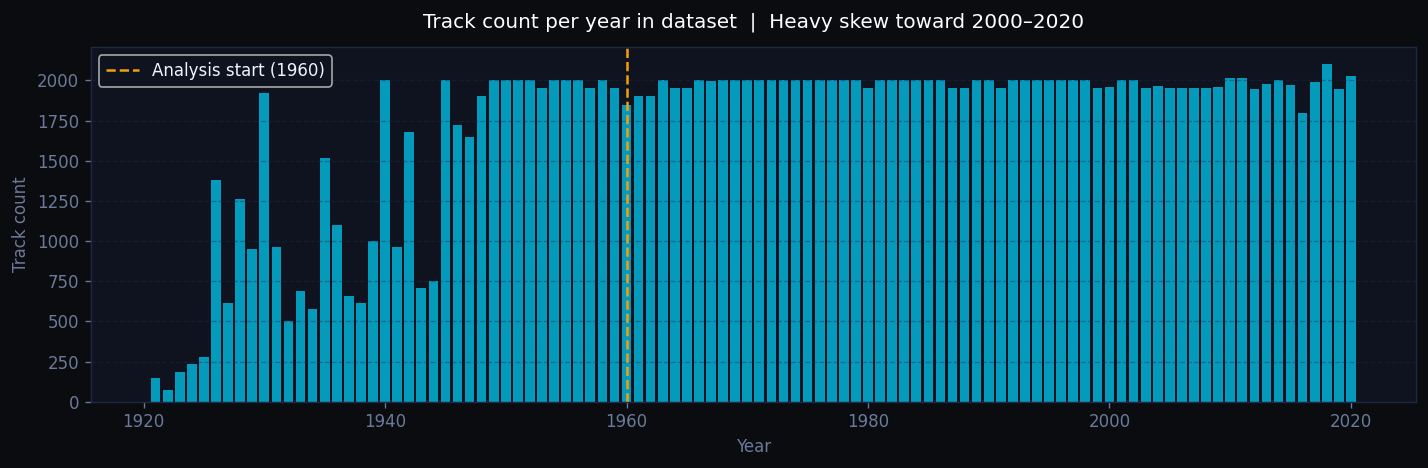

💾 Saved: track_density.png
NOTE: Pre-2000 data is thin. Means from sparse decades are less reliable.


In [18]:
#── Visual: track density over time ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Use main df if data_by_year doesn't have per-year counts
per_year = df_raw.groupby('year').size()

ax.bar(per_year.index, per_year.values, color=CYAN, alpha=0.7, width=0.8)
ax.axvline(1960, color=AMBER, linewidth=1.5, linestyle='--', label='Analysis start (1960)')
ax.set_xlabel('Year')
ax.set_ylabel('Track count')
ax.set_title('Track count per year in dataset  |  Heavy skew toward 2000–2020', color='white', pad=12)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('track_density.png', dpi=120, bbox_inches='tight')
plt.show()

print('💾 Saved: track_density.png')
print('NOTE: Pre-2000 data is thin. Means from sparse decades are less reliable.')

---
## 4. Cleaning Decisions
Every removal is documented here.Use this as reference for why rows were removed.

### Decision log:
| # | Removal criterion | Reason |
|---|---|---|
| 1 | `tempo == 0` | Ambient/noise tracks — not real songs |
| 2 | `duration_ms < 30_000` | Tracks under 30s are skits, intros, or sound effects |
| 3 | `duration_ms > 1_800_000` | Tracks over 30 min are likely mislabeled or podcasts |
| 4 | `year < 1960` | Pre-1960 data is very sparse; distorts decade averages |
| 5 | Exact duplicate rows | Same artist + track + year appearing multiple times |

In [19]:
# ── Apply all cleaning steps with counts logged ───────────────────────────────

df = df_raw.copy()
print(f'Starting rows: {len(df):,}')
print('-' * 40)

# Decision 1: Remove zero-tempo tracks
if 'tempo' in df.columns:
    n_before = len(df)
    df = df[df['tempo'] > 0]
    print(f'Removed (tempo == 0)              : {n_before - len(df):>6,} rows  → {len(df):,} remain')

# Decision 2: Remove sub-30-second tracks
if 'duration_ms' in df.columns:
    n_before = len(df)
    df = df[df['duration_ms'] >= 30_000]
    print(f'Removed (duration < 30s)          : {n_before - len(df):>6,} rows  → {len(df):,} remain')

# Decision 3: Remove tracks over 30 minutes
if 'duration_ms' in df.columns:
    n_before = len(df)
    df = df[df['duration_ms'] <= 1_800_000]
    print(f'Removed (duration > 30min)        : {n_before - len(df):>6,} rows  → {len(df):,} remain')

# Decision 4: Keep 1960 onward only
n_before = len(df)
df = df[df['year'] >= 1960]
print(f'Removed (year < 1960)             : {n_before - len(df):>6,} rows  → {len(df):,} remain')

# Decision 5: Drop exact duplicates
n_before = len(df)
df = df.drop_duplicates()
print(f'Removed (exact duplicate rows)    : {n_before - len(df):>6,} rows  → {len(df):,} remain')

print('-' * 40)
total_removed = len(df_raw) - len(df)
pct_removed   = total_removed / len(df_raw) * 100
print(f'TOTAL removed: {total_removed:,} rows  ({pct_removed:.1f}% of raw)')
print(f'FINAL clean dataset: {len(df):,} rows')

Starting rows: 170,653
----------------------------------------
Removed (tempo == 0)              :    143 rows  → 170,510 remain
Removed (duration < 30s)          :    158 rows  → 170,352 remain
Removed (duration > 30min)        :    109 rows  → 170,243 remain
Removed (year < 1960)             : 49,647 rows  → 120,596 remain
Removed (exact duplicate rows)    :      0 rows  → 120,596 remain
----------------------------------------
TOTAL removed: 50,057 rows  (29.3% of raw)
FINAL clean dataset: 120,596 rows


In [20]:
# ── Post-clean null check ─────────────────────────────────────────────────────
# Verify no surprise nulls remain in the key analysis columns

KEY_COLS = ['year', 'valence', 'energy', 'acousticness',
            'loudness', 'danceability', 'tempo', 'popularity']
KEY_COLS = [c for c in KEY_COLS if c in df.columns]

post_null = df[KEY_COLS].isnull().sum()
print('POST-CLEAN NULL CHECK (key columns only):')
print(post_null.to_string())

if post_null.sum() > 0:
    print()
    print('⚠️  Some nulls remain. Consider dropping rows with null in these columns.')
    print('   Adding a final dropna on key columns:')
    n_before = len(df)
    df = df.dropna(subset=KEY_COLS)
    print(f'   Removed additional {n_before - len(df):,} null rows → {len(df):,} remain')
else:
    print('✅ No nulls in key columns. No further action needed.')

POST-CLEAN NULL CHECK (key columns only):
year            0
valence         0
energy          0
acousticness    0
loudness        0
danceability    0
tempo           0
popularity      0
✅ No nulls in key columns. No further action needed.


---
## 5. Create the Decade Column & Track Count Validation

In [21]:
# ── Add decade column ─────────────────────────────────────────────────────────
df['decade'] = (df['year'] // 10) * 10

# ── Track counts per decade in clean data ────────────────────────────────────
decade_counts = df['decade'].value_counts().sort_index()

print('CLEAN TRACK COUNTS BY DECADE')
print('=' * 40)
for decade, count in decade_counts.items():
    bar = '█' * min(int(count / 500), 40)
    flag = '  ⚠️ sparse' if count < 1_000 else ''
    print(f'  {int(decade)}s : {count:>7,}  {bar}{flag}')

print()
print('Rule of thumb: < 1,000 tracks → treat that decade\'s averages with caution.')
print('Decades with good coverage (>= 1,000):', list(decade_counts[decade_counts >= 1000].index))

CLEAN TRACK COUNTS BY DECADE
  1960s :  19,508  ███████████████████████████████████████
  1970s :  19,988  ███████████████████████████████████████
  1980s :  19,846  ███████████████████████████████████████
  1990s :  19,895  ███████████████████████████████████████
  2000s :  19,630  ███████████████████████████████████████
  2010s :  19,700  ███████████████████████████████████████
  2020s :   2,029  ████

Rule of thumb: < 1,000 tracks → treat that decade's averages with caution.
Decades with good coverage (>= 1,000): [1960, 1970, 1980, 1990, 2000, 2010, 2020]


In [22]:
# ── Decade label column (string) for charts  ──────────────────────────────────
# e.g. 1960 → '1960s'  Makes axis labels cleaner later charts
df['decade_label'] = df['decade'].astype(str) + 's'

# Also add a popularity tier column — Persons 2 & 3 use this for filtering
# Low: 0–39  |  Mid: 40–59  |  Popular: 60–74  |  Hit: 75+
df['pop_tier'] = pd.cut(
    df['popularity'],
    bins=[-1, 39, 59, 74, 100],
    labels=['Low (0–39)', 'Mid (40–59)', 'Popular (60–74)', 'Hit (75+)']
)

print('New columns added:')
print(f'  decade        : integer decade (1960, 1970 ... 2020)')
print(f'  decade_label  : string label ("1960s", "1970s" ... "2020s")')
print(f'  pop_tier      : popularity bracket for easy filtering')
print()
print('pop_tier distribution:')
print(df['pop_tier'].value_counts().sort_index().to_string())

New columns added:
  decade        : integer decade (1960, 1970 ... 2020)
  decade_label  : string label ("1960s", "1970s" ... "2020s")
  pop_tier      : popularity bracket for easy filtering

pop_tier distribution:
pop_tier
Low (0–39)         53279
Mid (40–59)        49900
Popular (60–74)    15342
Hit (75+)           2075


In [23]:
# ── Quick sanity-check: feature distributions per decade ─────────────────────
# Run this to confirm there's real signal

SIGNAL_COLS = ['valence', 'loudness', 'acousticness', 'energy', 'danceability']
SIGNAL_COLS = [c for c in SIGNAL_COLS if c in df.columns]

preview = df.groupby('decade_label')[SIGNAL_COLS].mean().round(4)

print('DECADE MEAN PREVIEW (all tracks — unfiltered)')
print('Persons 2 & 3: use these as a rough directional check before applying popularity filters')
print('=' * 70)
print(preview.to_string())

DECADE MEAN PREVIEW (all tracks — unfiltered)
Persons 2 & 3: use these as a rough directional check before applying popularity filters
              valence  loudness  acousticness  energy  danceability
decade_label                                                       
1960s          0.5525  -12.6760        0.6237  0.4145        0.4951
1970s          0.5854  -11.4213        0.4001  0.5338        0.5251
1980s          0.5645  -11.2260        0.2986  0.5948        0.5464
1990s          0.5451  -10.0000        0.3075  0.5862        0.5662
2000s          0.5307   -7.4857        0.2695  0.6520        0.5745
2010s          0.4581   -7.4478        0.2634  0.6307        0.5996
2020s          0.5013   -6.5832        0.2196  0.6315        0.6932


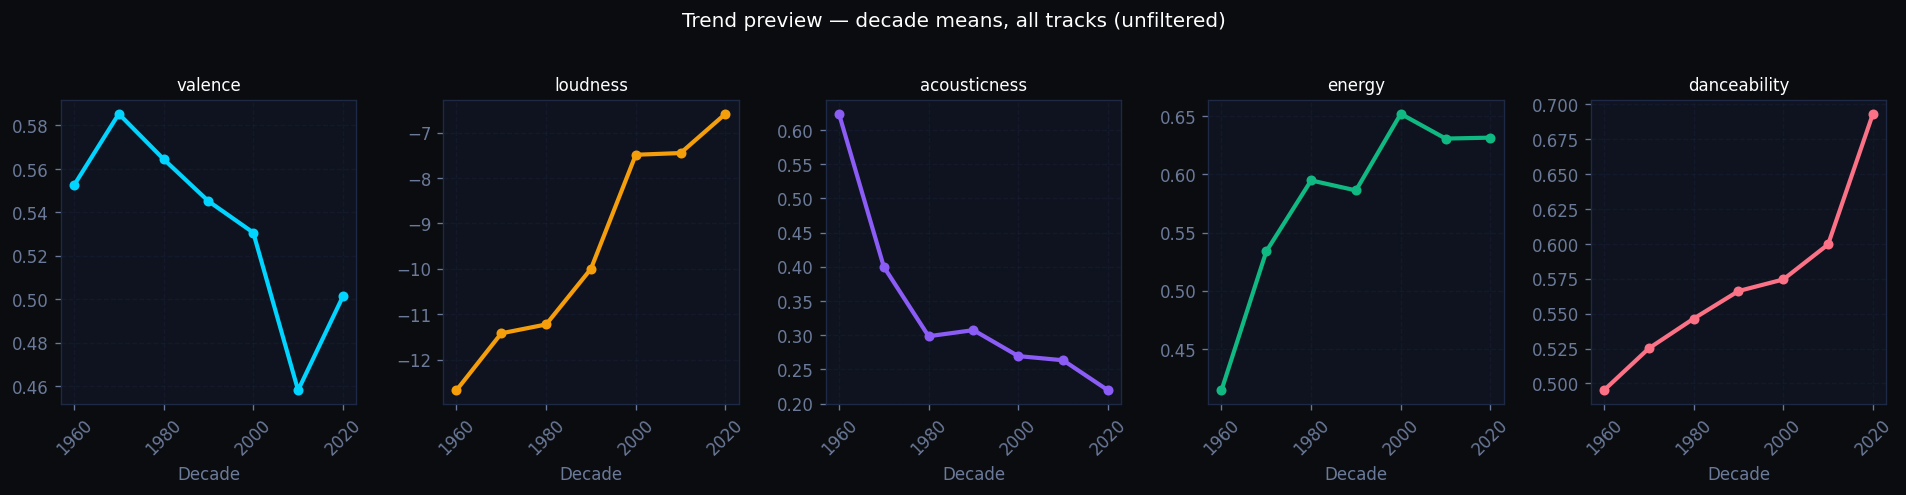

💾 Saved: trend_preview.png


In [24]:
# ── Quick 5-panel trend preview chart ────────────────────────────────────────
fig, axes = plt.subplots(1, len(SIGNAL_COLS), figsize=(16, 4), sharey=False)
colors = [CYAN, AMBER, PURPLE, GREEN, '#FB7185']

for ax, col, color in zip(axes, SIGNAL_COLS, colors):
    vals = df.groupby('decade')[col].mean()
    ax.plot(vals.index, vals.values, color=color, linewidth=2.5, marker='o', markersize=5)
    ax.set_title(col, color='white', fontsize=10)
    ax.set_xlabel('Decade')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

fig.suptitle('Trend preview — decade means, all tracks (unfiltered)', color='white', y=1.02)
plt.tight_layout()
plt.savefig('trend_preview.png', dpi=120, bbox_inches='tight')
plt.show()

print('💾 Saved: trend_preview.png')

---
## 6. Sample Track Lookup for Slide 3
Look up the 5 specific tracks used in the deck and extract real feature values.

In [25]:
# ── Check what column names hold artist and track ─────────────────────────────
# Common variants: 'artists' / 'name' or 'artist_name' / 'track_name'

print('Columns containing "artist" or "name":')
for col in df.columns:
    if any(kw in col.lower() for kw in ['artist', 'name', 'track', 'title']):
        sample_vals = df[col].dropna().head(3).tolist()
        print(f'  {col:<25} → sample: {sample_vals}')

Columns containing "artist" or "name":
  artists                   → sample: ["['Etta James']", "['Etta James']", "['Ella Fitzgerald']"]
  name                      → sample: ['At Last', 'A Sunday Kind Of Love', 'Sleigh Ride']


In [26]:
# ── UPDATE THESE to match the actual column names printed above ───────────────
# Most likely: ARTIST_COL = 'artists'  and  TRACK_COL = 'name'
# But check the output of the cell above first!

ARTIST_COL = 'artists'   # ← change if needed
TRACK_COL  = 'name'      # ← change if needed

# ── Define the 5 landmark tracks from the slide ───────────────────────────────
LANDMARK_TRACKS = [
    ('The Beatles',     'Let It Be'),
    ('Michael Jackson', 'Thriller'),
    ('Nirvana',         'Smells Like Teen Spirit'),
    ('Taylor Swift',    'Shake It Off'),
    ('Billie Eilish',   'bad guy'),
]

# ── Columns to pull for the slide table ──────────────────────────────────────
TABLE_COLS = [ARTIST_COL, TRACK_COL, 'year', 'energy', 'valence',
              'acousticness', 'popularity']
TABLE_COLS = [c for c in TABLE_COLS if c in df.columns]

results = []

for artist, track in LANDMARK_TRACKS:
    # Search: lowercase both sides for robustness
    mask = (
        df[ARTIST_COL].str.lower().str.contains(artist.lower(), na=False) &
        df[TRACK_COL].str.lower().str.contains(track.lower(), na=False)
    )
    matches = df[mask][TABLE_COLS]

    if len(matches) == 0:
        print(f'  ❌ NOT FOUND: {artist} — {track}')
        print(f'     → Try manual search below')
    elif len(matches) == 1:
        results.append(matches.iloc[0])
        print(f'  ✅ Found : {artist} — {track}')
    else:
        # Multiple matches → pick the one with highest popularity
        best = matches.sort_values('popularity', ascending=False).iloc[0]
        results.append(best)
        print(f'  ✅ Found ({len(matches)} matches, took highest popularity): {artist} — {track}')

print()

  ✅ Found (4 matches, took highest popularity): The Beatles — Let It Be
  ✅ Found (14 matches, took highest popularity): Michael Jackson — Thriller
  ✅ Found (5 matches, took highest popularity): Nirvana — Smells Like Teen Spirit
  ✅ Found (3 matches, took highest popularity): Taylor Swift — Shake It Off
  ✅ Found (2 matches, took highest popularity): Billie Eilish — bad guy



In [27]:
# ── Display the real Slide 3 table ────────────────────────────────────────────
if results:
    slide3_table = pd.DataFrame(results).reset_index(drop=True)

    # Round for clean display
    for col in ['energy', 'valence', 'acousticness']:
        if col in slide3_table.columns:
            slide3_table[col] = slide3_table[col].round(2)

    print('REAL VALUES FOR SLIDE 3 SAMPLE TABLE')
    print('Copy these into the PPTX — replace every placeholder number')
    print('=' * 65)
    print(slide3_table[[ARTIST_COL, TRACK_COL, 'year', 'energy',
                         'valence', 'acousticness', 'popularity']].to_string(index=False))
else:
    print('No tracks found — check ARTIST_COL and TRACK_COL variable names above.')

REAL VALUES FOR SLIDE 3 SAMPLE TABLE
Copy these into the PPTX — replace every placeholder number
            artists                        name  year  energy  valence  acousticness  popularity
    ['The Beatles'] Let It Be - Remastered 2009  1970    0.40     0.41          0.63          78
['Michael Jackson']                    Thriller  2017    0.89     0.72          0.08          73
        ['Nirvana']     Smells Like Teen Spirit  1991    0.91     0.72          0.00          75
   ['Taylor Swift']                Shake It Off  2014    0.78     0.94          0.06          70
  ['Billie Eilish']                     bad guy  2019    0.42     0.56          0.33          88


In [28]:
# ── Manual search helper — use this if any track was NOT FOUND above ──────────
# Change the search string and run this cell

SEARCH_ARTIST = 'Billie'    # ← part of artist name
SEARCH_TRACK  = 'bad'       # ← part of track name

manual_mask = (
    df[ARTIST_COL].str.lower().str.contains(SEARCH_ARTIST.lower(), na=False) &
    df[TRACK_COL].str.lower().str.contains(SEARCH_TRACK.lower(), na=False)
)
manual_results = df[manual_mask][TABLE_COLS].sort_values('popularity', ascending=False)

print(f'Search: artist contains "{SEARCH_ARTIST}" AND track contains "{SEARCH_TRACK}"')
print(f'Results: {len(manual_results)} match(es)')
print()
if len(manual_results) > 0:
    print(manual_results.head(5).to_string(index=False))
else:
    print('No results. Try a shorter or differently spelled search string.')

Search: artist contains "Billie" AND track contains "bad"
Results: 2 match(es)

                           artists                         name  year  energy  valence  acousticness  popularity
                 ['Billie Eilish']                      bad guy  2019   0.425    0.562         0.328          88
['Billie Eilish', 'Justin Bieber'] bad guy (with Justin Bieber)  2019   0.453    0.680         0.252          75


---
## 7. Save `spotify_clean.csv`
This is cleaned csv the file. **Do not modify after this point.**

In [29]:
# ── Final column confirmation before saving ───────────────────────────────────
print('FINAL CLEAN DATAFRAME SUMMARY')
print('=' * 45)
print(f'  Rows                   : {len(df):,}')
print(f'  Columns                : {len(df.columns)}')
print(f'  Year range             : {df["year"].min()} – {df["year"].max()}')
print(f'  Decades covered        : {sorted(df["decade"].unique().tolist())}')
print(f'  Nulls in key columns   : {df[KEY_COLS].isnull().sum().sum()}')
print()
print('Columns in output file:')
print(list(df.columns))

FINAL CLEAN DATAFRAME SUMMARY
  Rows                   : 120,596
  Columns                : 22
  Year range             : 1960 – 2020
  Decades covered        : [1960, 1970, 1980, 1990, 2000, 2010, 2020]
  Nulls in key columns   : 0

Columns in output file:
['valence', 'year', 'acousticness', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo', 'decade', 'decade_label', 'pop_tier']


In [30]:
# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv(PATH_OUTPUT, index=False)

print(f'✅ Saved: {PATH_OUTPUT}')
print()
print('Share this file with Persons 2 & 3.')
print('They load it with:  df = pd.read_csv("spotify_clean.csv")')

✅ Saved: ./spotify_clean.csv

Share this file with Persons 2 & 3.
They load it with:  df = pd.read_csv("spotify_clean.csv")


---
## 8. Summary Report — Numbers for the Slide 3
Run this cell last. Copy every number in the output directly into the PPTX.

In [31]:
# ── Compile all SLIDE 3 stats ─────────────────────────────────────────────────
raw_rows    = len(df_raw)
clean_rows  = len(df)
raw_cols    = df_raw.shape[1]
year_min    = df['year'].min()
year_max    = df['year'].max()
null_pct_raw   = (df_raw.isnull().sum().sum() / df_raw.size * 100)
null_pct_clean = (df[KEY_COLS].isnull().sum().sum() / (len(df) * len(KEY_COLS)) * 100)

print('╔══════════════════════════════════════════════════════════╗')
print('║          SLIDE 3 — NUMBERS TO COPY INTO PPTX            ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Raw track count        : {raw_rows:>10,}                  ║')
print(f'║  Clean track count      : {clean_rows:>10,}                  ║')
print(f'║  Raw column count       : {raw_cols:>10}                  ║')
print(f'║  Year range (clean)     :  {year_min}  –  {year_max}            ║')
print(f'║  Missing values (raw)   : {null_pct_raw:>9.2f}%                  ║')
print(f'║  Missing in key cols    : {null_pct_clean:>9.2f}%                  ║')
print('╚══════════════════════════════════════════════════════════╝')

print()
print('╔══════════════════════════════════════════════════════════╗')
print('║        DECADE TRACK COUNTS (for slide speaker notes)    ║')
print('╠══════════════════════════════════════════════════════════╣')
for decade, count in df['decade'].value_counts().sort_index().items():
    flag = ' ⚠️' if count < 1000 else '   '
    print(f'║  {int(decade)}s : {count:>8,} tracks{flag}                        ║')
print('╚══════════════════════════════════════════════════════════╝')

print()
print('FOR NEXT STEPS:')
print('─' * 55)
print('Unfiltered decade means (reference baseline):')
preview_cols = ['valence', 'loudness', 'acousticness', 'energy', 'danceability']
preview_cols = [c for c in preview_cols if c in df.columns]
print(df.groupby('decade')[preview_cols].mean().round(3).to_string())

╔══════════════════════════════════════════════════════════╗
║          SLIDE 3 — NUMBERS TO COPY INTO PPTX            ║
╠══════════════════════════════════════════════════════════╣
║  Raw track count        :    170,653                  ║
║  Clean track count      :    120,596                  ║
║  Raw column count       :         19                  ║
║  Year range (clean)     :  1960  –  2020            ║
║  Missing values (raw)   :      0.00%                  ║
║  Missing in key cols    :      0.00%                  ║
╚══════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════╗
║        DECADE TRACK COUNTS (for slide speaker notes)    ║
╠══════════════════════════════════════════════════════════╣
║  1960s :   19,508 tracks                           ║
║  1970s :   19,988 tracks                           ║
║  1980s :   19,846 tracks                           ║
║  1990s :   19,895 tracks                           ║
║  2000s

---
## Handoff Notes

**Load the clean file:**
```python
import pandas as pd
df = pd.read_csv('spotify_clean.csv')
```

**Key columns available:**
- `decade` — integer: 1960, 1970 ... 2020
- `decade_label` — string: '1960s', '1970s' ... '2020s'
- `pop_tier` — 'Low (0–39)', 'Mid (40–59)', 'Popular (60–74)', 'Hit (75+)'
- `valence`, `energy`, `acousticness`, `loudness`, `danceability`, `tempo`, `speechiness`
- `popularity` — 0 to 100

**Findings 1 & 2 (Finding 1 done for Slide 9):**
- Filter for popular tracks: `df_pop = df[df['popularity'] >= 60]`
- Compute decade means: `df_pop.groupby('decade')[['valence', 'loudness']].mean()`
- Test at thresholds 50, 60, 70 to find where trend is cleanest

**Finding 3 + surprise:**
- Use all tracks for acousticness (loudness war wasn't just hits)
- Check danceability trend vs. valence trend — this is the surprise
- Normalize to 1960s baseline: `vals / vals.iloc[0] * 100`

**Sparse decade warning:**
Check the decade counts above. Any decade flagged ⚠️ means fewer tracks, less reliable means. Note this in speaker notes when presenting those data points.

**Cleaning decisions made (do not re-apply):**
- Removed tempo = 0 tracks (ambient/noise)
- Removed tracks < 30s or > 30min
- Removed tracks before 1960
- Removed exact duplicate rows
- Dropped rows with nulls in key analysis columns

## Findings for Slides 9

**Input:** `spotify_clean.csv` (produced by Person 1 notebook)

---
> **For Next Steps:** The baseline unfiltered decade means from Section 3 are your reference for normalizing the trifecta chart.

In [32]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0A0C10', 'axes.facecolor':  '#0F1320',
    'axes.edgecolor':   '#1E2A45', 'axes.labelcolor': '#6B7A99',
    'xtick.color':      '#6B7A99', 'ytick.color':     '#6B7A99',
    'text.color':       '#F0F4FF', 'grid.color':      '#1E2A45',
    'grid.linestyle':   '--',      'figure.dpi':      130,
})
CYAN = '#00D4FF'; PURPLE = '#8B5CF6'; AMBER = '#F59E0B'
GREEN = '#10B981'; MUTED = '#6B7A99'; RED = '#FB7185'
WHITE = '#F0F4FF'

df = pd.read_csv('./spotify_clean.csv')

required = ['year','decade','decade_label','valence','loudness',
            'acousticness','energy','danceability','popularity']
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    print(f'Missing columns: {missing_cols} — check Person 1 output')
else:
    print('All required columns present')
print(f'Rows: {len(df):,} | Decades: {sorted(df["decade"].unique().tolist())}')

All required columns present
Rows: 120,596 | Decades: [1960, 1970, 1980, 1990, 2000, 2010, 2020]


---
## 2. Popularity Filter Decision

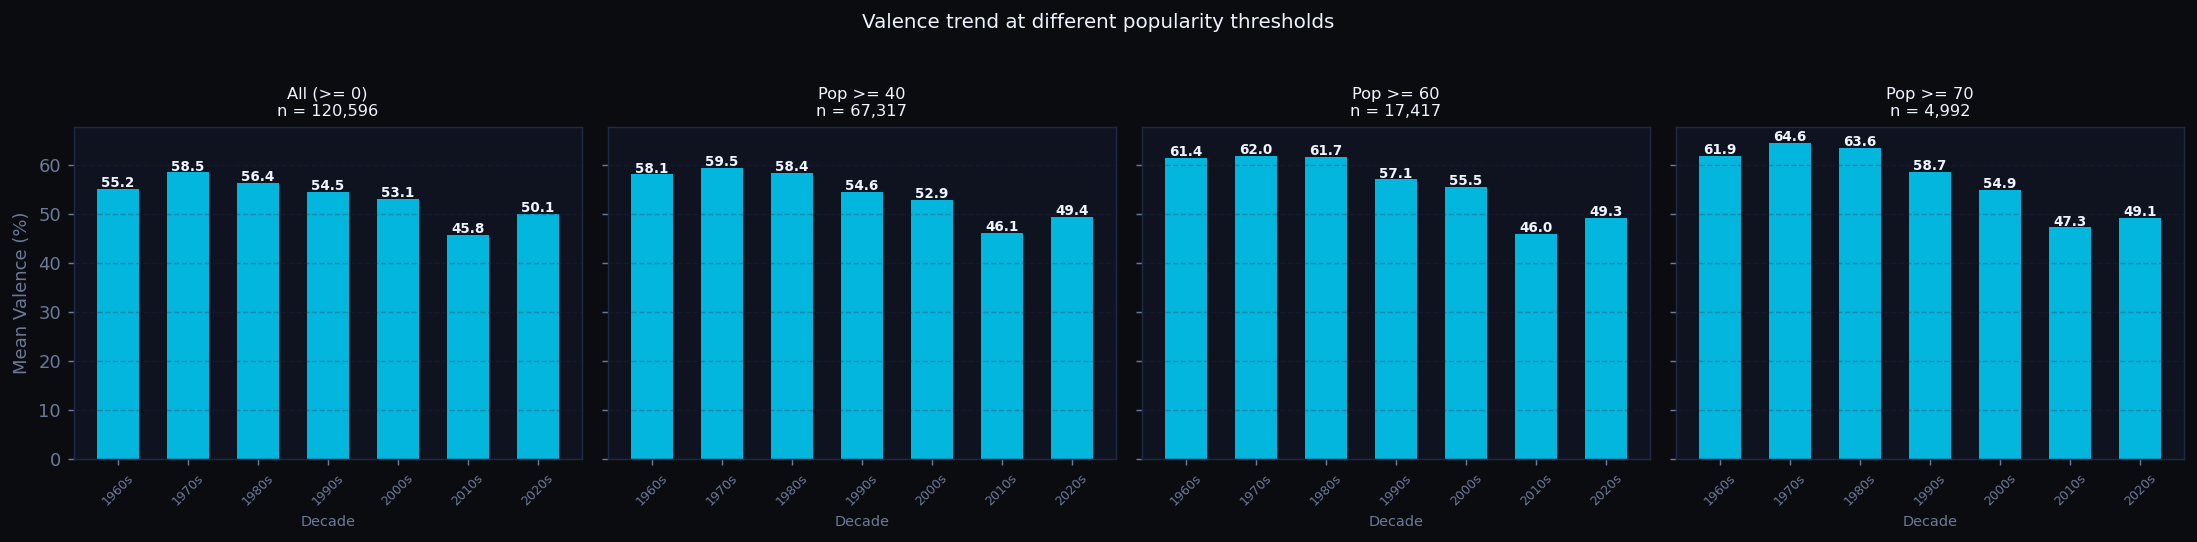

NUMERIC TABLE:
        All (>= 0)  Pop >= 40  Pop >= 60  Pop >= 70
decade                                             
1960          55.2       58.1       61.4       61.9
1970          58.5       59.5       62.0       64.6
1980          56.4       58.4       61.7       63.6
1990          54.5       54.6       57.1       58.7
2000          53.1       52.9       55.5       54.9
2010          45.8       46.1       46.0       47.3
2020          50.1       49.4       49.3       49.1


In [33]:
# Run valence-by-decade at 4 thresholds to pick the cleanest signal
thresholds = {'All (>= 0)': 0, 'Pop >= 40': 40, 'Pop >= 60': 60, 'Pop >= 70': 70}

fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
stored = {}

for ax, (label, thresh) in zip(axes, thresholds.items()):
    subset = df[df['popularity'] >= thresh]
    by_dec = subset.groupby('decade')['valence'].mean() * 100
    stored[thresh] = by_dec

    bars = ax.bar([str(int(d))+'s' for d in by_dec.index],
                  by_dec.values, color=CYAN, alpha=0.85, width=0.6)
    for bar, v in zip(bars, by_dec.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', fontsize=7.5, color=WHITE, fontweight='bold')

    ax.set_title(f'{label}\nn = {len(subset):,}', color=WHITE, fontsize=9, pad=6)
    ax.set_xlabel('Decade', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Mean Valence (%)')

fig.suptitle('Valence trend at different popularity thresholds',
             color=WHITE, y=1.03, fontsize=11)
plt.tight_layout()
plt.savefig('p2_threshold_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

print('NUMERIC TABLE:')
comp_df = pd.DataFrame({label: stored[t] for label, t in thresholds.items()}).round(1)
print(comp_df.to_string())

In [34]:
THRESHOLD = 60

df_pop = df[df['popularity'] >= THRESHOLD].copy()
dec_counts = df_pop['decade'].value_counts().sort_index()

print(f'Using: popularity >= {THRESHOLD}')
print(f'Tracks kept: {len(df_pop):,} ({len(df_pop)/len(df)*100:.1f}% of clean dataset)\n')
print('Tracks per decade at this threshold:')
for dec, n in dec_counts.items():
    flag = '  WARNING: LOW' if n < 100 else ''
    print(f'  {int(dec)}s : {n:>6,}{flag}')

Using: popularity >= 60
Tracks kept: 17,417 (14.4% of clean dataset)

Tracks per decade at this threshold:
  1960s :    397
  1970s :    810
  1980s :    835
  1990s :  1,577
  2000s :  2,781
  2010s :  9,350
  2020s :  1,667


---
## 3. Slide 9 — Valence Decline
### 3a. Decade statistics

In [35]:
val_stats = df_pop.groupby('decade')['valence'].agg(
    mean='mean', median='median', std='std', count='count'
).round(4)
val_stats['mean_pct']   = (val_stats['mean']   * 100).round(1)
val_stats['median_pct'] = (val_stats['median'] * 100).round(1)

print(f'VALENCE BY DECADE  (popularity >= {THRESHOLD})')
print('=' * 55)
print(val_stats[['mean_pct', 'median_pct', 'std', 'count']].to_string())

peak_dec    = int(val_stats['mean_pct'].idxmax())
trough_dec  = int(val_stats['mean_pct'].idxmin())
peak_val    = val_stats['mean_pct'].max()
trough_val  = val_stats['mean_pct'].min()
total_drop  = peak_val - trough_val

diffs = val_stats['mean_pct'].diff()
worst_drop_end   = int(diffs.idxmin())
worst_drop_start = int(val_stats.index[list(val_stats.index).index(worst_drop_end) - 1])
worst_drop_pp    = diffs.min()

print(f'\nPeak decade        : {peak_dec}s  -> {peak_val}%')
print(f'Trough decade      : {trough_dec}s  -> {trough_val}%')
print(f'Total drop         : {total_drop:.1f} pp  ({total_drop/peak_val*100:.1f}% of peak)')
print(f'Steepest drop      : {worst_drop_start}s to {worst_drop_end}s  ({worst_drop_pp:.1f} pp)')

VALENCE BY DECADE  (popularity >= 60)
        mean_pct  median_pct     std  count
decade                                     
1960        61.4        64.6  0.2362    397
1970        62.0        65.2  0.2409    810
1980        61.7        63.7  0.2419    835
1990        57.1        58.8  0.2485   1577
2000        55.5        56.6  0.2445   2781
2010        46.0        44.6  0.2360   9350
2020        49.3        50.0  0.2206   1667

Peak decade        : 1970s  -> 62.0%
Trough decade      : 2010s  -> 46.0%
Total drop         : 16.0 pp  (25.8% of peak)
Steepest drop      : 2000s to 2010s  (-9.5 pp)


### 3b. The 1980s bump check — is this the counterintuitive hook?

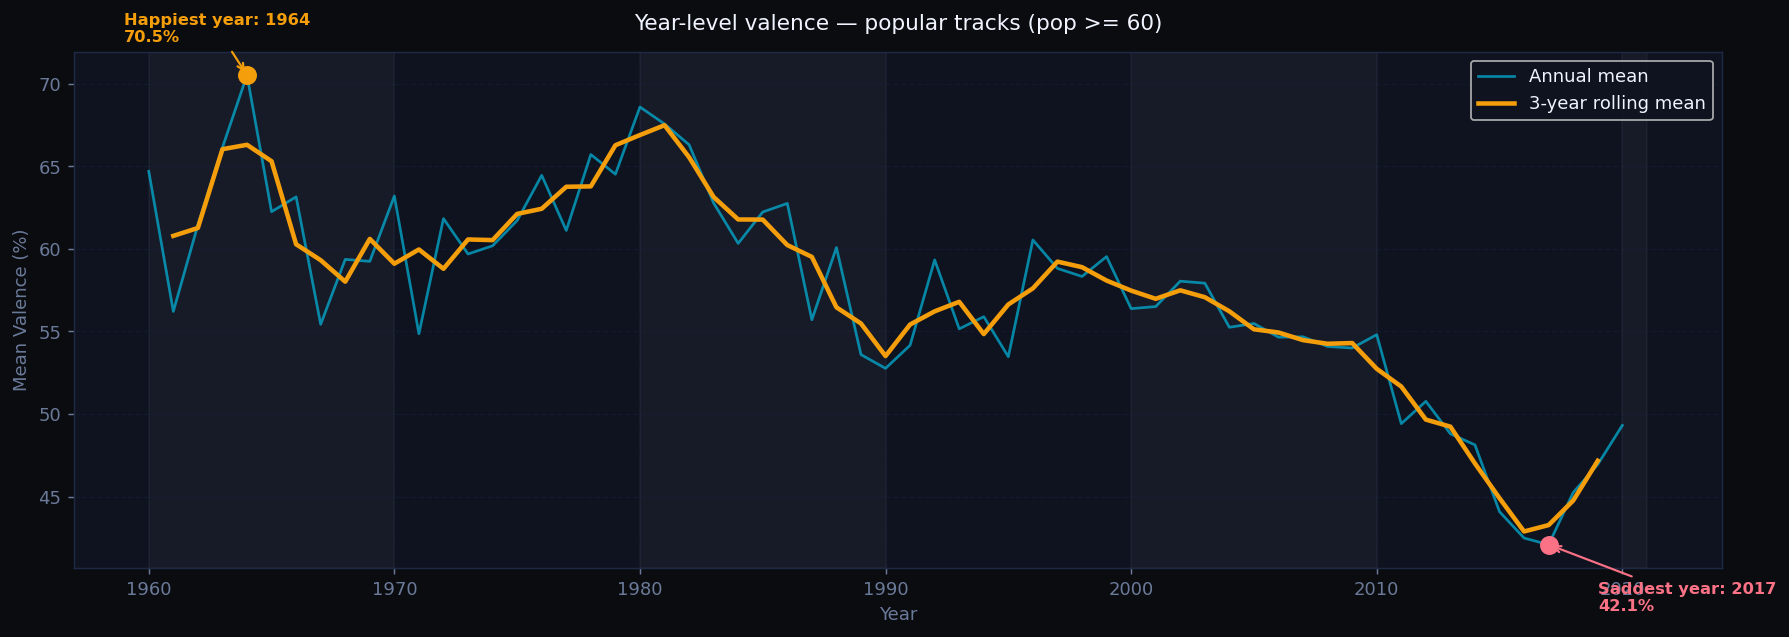

1970s=62.0%  vs  1980s=61.7%  =>  1980s went DOWN


In [36]:
# Year-level valence to spot the 1980s bump before the crash
year_valence = df_pop.groupby('year')['valence'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(year_valence.index, year_valence.values,
        color=CYAN, linewidth=1.5, alpha=0.6, label='Annual mean')

rolling = year_valence.rolling(3, center=True).mean()
ax.plot(rolling.index, rolling.values,
        color=AMBER, linewidth=2.5, label='3-year rolling mean')

# Shade each decade
for d in range(1960, 2025, 20):
    ax.axvspan(d, min(d+10, 2021), alpha=0.04, color=WHITE)

# Mark single happiest and saddest years
py = year_valence.idxmax(); pv = year_valence.max()
ty = year_valence.idxmin(); tv = year_valence.min()
ax.scatter([py], [pv], color=AMBER, s=90, zorder=5)
ax.annotate(f'Happiest year: {py}\n{pv:.1f}%',
            (py, pv), xytext=(py-5, pv+2),
            color=AMBER, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2))
ax.scatter([ty], [tv], color=RED, s=90, zorder=5)
ax.annotate(f'Saddest year: {ty}\n{tv:.1f}%',
            (ty, tv), xytext=(ty+2, tv-4),
            color=RED, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_xlabel('Year')
ax.set_ylabel('Mean Valence (%)')
ax.set_title(f'Year-level valence — popular tracks (pop >= {THRESHOLD})',
             color=WHITE, pad=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p2_year_valence.png', dpi=130, bbox_inches='tight')
plt.show()

# Report the 1970s vs 1980s comparison
if 1970 in val_stats.index and 1980 in val_stats.index:
    v70 = val_stats.loc[1970, 'mean_pct']
    v80 = val_stats.loc[1980, 'mean_pct']
    direction = 'UP' if v80 > v70 else 'DOWN'
    print(f'1970s={v70:.1f}%  vs  1980s={v80:.1f}%  =>  1980s went {direction}')
    if v80 > v70:
        print('COUNTERINTUITIVE HOOK CONFIRMED: 1980s were happier than 1970s')
        print('Narrative: "The 80s were the happiest decade on record.')
        print('          The crash that followed makes the decline even more dramatic."')

### 3c. Slide 9 final chart

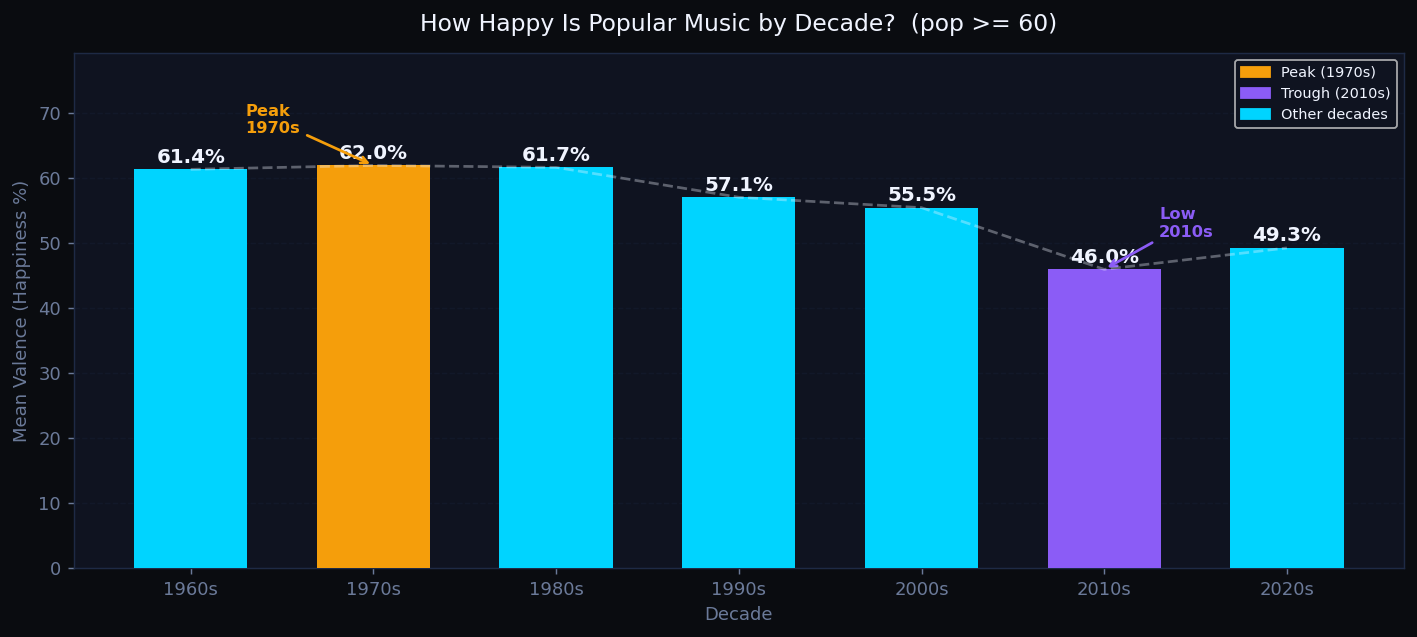

Saved: slide9_valence_chart.png  <- use this in PPTX Slide 9


In [37]:
decades_v = val_stats.index.astype(int).tolist()
vals_v    = val_stats['mean_pct'].values
labels_v  = [str(d)+'s' for d in decades_v]

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = [AMBER if d == peak_dec else PURPLE if d == trough_dec else CYAN
              for d in decades_v]

bars = ax.bar(labels_v, vals_v, color=bar_colors, width=0.62,
              edgecolor='none', zorder=3)

for bar, val in zip(bars, vals_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, color=WHITE, fontweight='bold')

# Trend line
ax.plot(range(len(decades_v)), vals_v, color=WHITE, linewidth=1.5,
        linestyle='--', alpha=0.35, zorder=4)

# Annotations
pi = decades_v.index(peak_dec)
ti = decades_v.index(trough_dec)
ax.annotate(f'Peak\n{peak_dec}s', xy=(pi, vals_v[pi]),
            xytext=(pi - 0.7, vals_v[pi] + 5), color=AMBER,
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.5))
ax.annotate(f'Low\n{trough_dec}s', xy=(ti, vals_v[ti]),
            xytext=(ti + 0.3, vals_v[ti] + 5), color=PURPLE,
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.5))

ax.set_ylabel('Mean Valence (Happiness %)')
ax.set_xlabel('Decade')
ax.set_ylim(0, max(vals_v) * 1.28)
ax.set_title(f'How Happy Is Popular Music by Decade?  (pop >= {THRESHOLD})',
             color=WHITE, pad=12, fontsize=13)
ax.grid(axis='y', alpha=0.25, zorder=0)

patches = [mpatches.Patch(color=AMBER,  label=f'Peak ({peak_dec}s)'),
           mpatches.Patch(color=PURPLE, label=f'Trough ({trough_dec}s)'),
           mpatches.Patch(color=CYAN,   label='Other decades')]
ax.legend(handles=patches, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('slide9_valence_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slide9_valence_chart.png  <- use this in PPTX Slide 9')

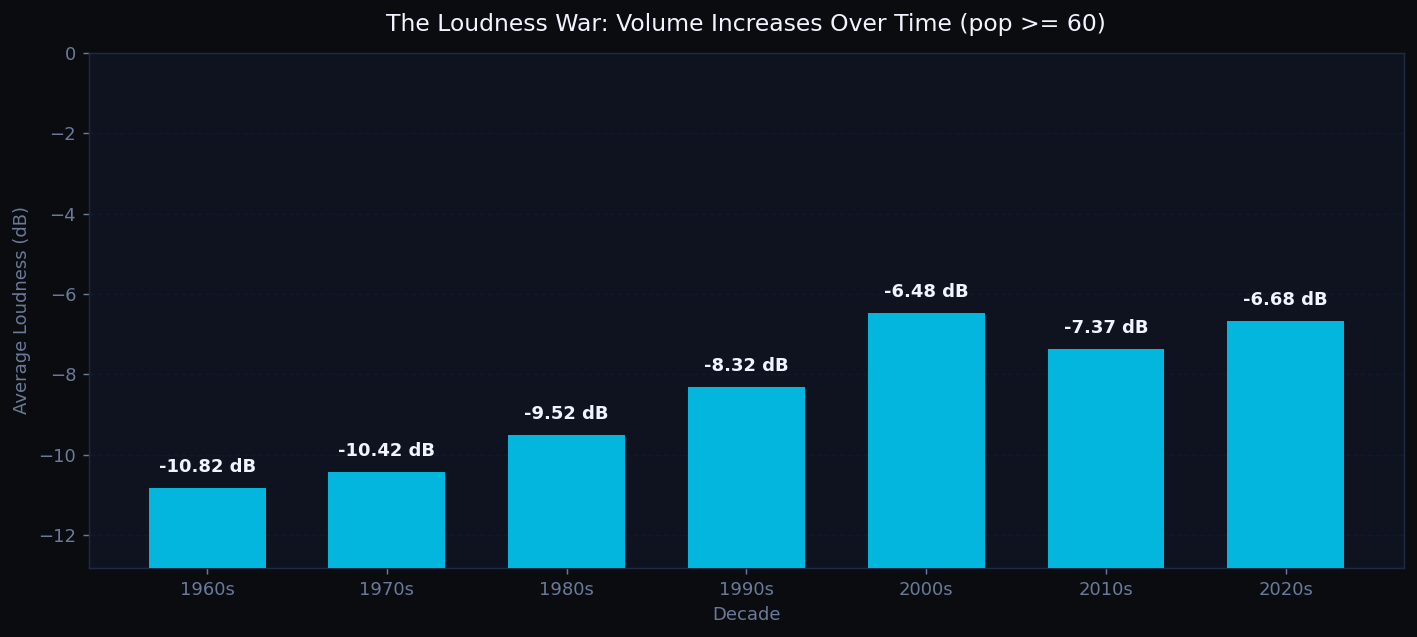

Saved: slide_loudness_chart.png


In [38]:
# ── Loudness Bar Chart ────────────────────────────────────────────────────────
# Reverting to df_pop (Popularity >= 60) as requested

# Calculate mean loudness per decade on the POPULAR tracks
loud_stats = df_pop.groupby('decade')['loudness'].mean().round(2)

decades_l = loud_stats.index.astype(int).tolist()
vals_l    = loud_stats.values
labels_l  = [str(d)+'s' for d in decades_l]

fig, ax = plt.subplots(figsize=(11, 5))

# Staircase effect: Set a floor slightly lower than the minimum value
floor = min(vals_l) - 2

# The bar height is the distance from the floor to the value
heights = vals_l - floor

# Plot bars starting from the 'floor'
bars = ax.bar(labels_l, heights, bottom=floor, color=CYAN, width=0.65,
              edgecolor='none', alpha=0.85, zorder=3)

# Add labels above bars
for bar, val in zip(bars, vals_l):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val} dB', ha='center', va='bottom',
            fontsize=10, color=WHITE, fontweight='bold')

ax.set_ylabel('Average Loudness (dB)')
ax.set_xlabel('Decade')
ax.set_title(f'The Loudness War: Volume Increases Over Time (pop >= {THRESHOLD})',
             color=WHITE, pad=12, fontsize=13)
ax.grid(axis='y', alpha=0.25, zorder=0)

# Set y-axis limits to start at our floor and end at 0
ax.set_ylim(floor, 0)

plt.tight_layout()
plt.savefig('slide_loudness_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: slide_loudness_chart.png')

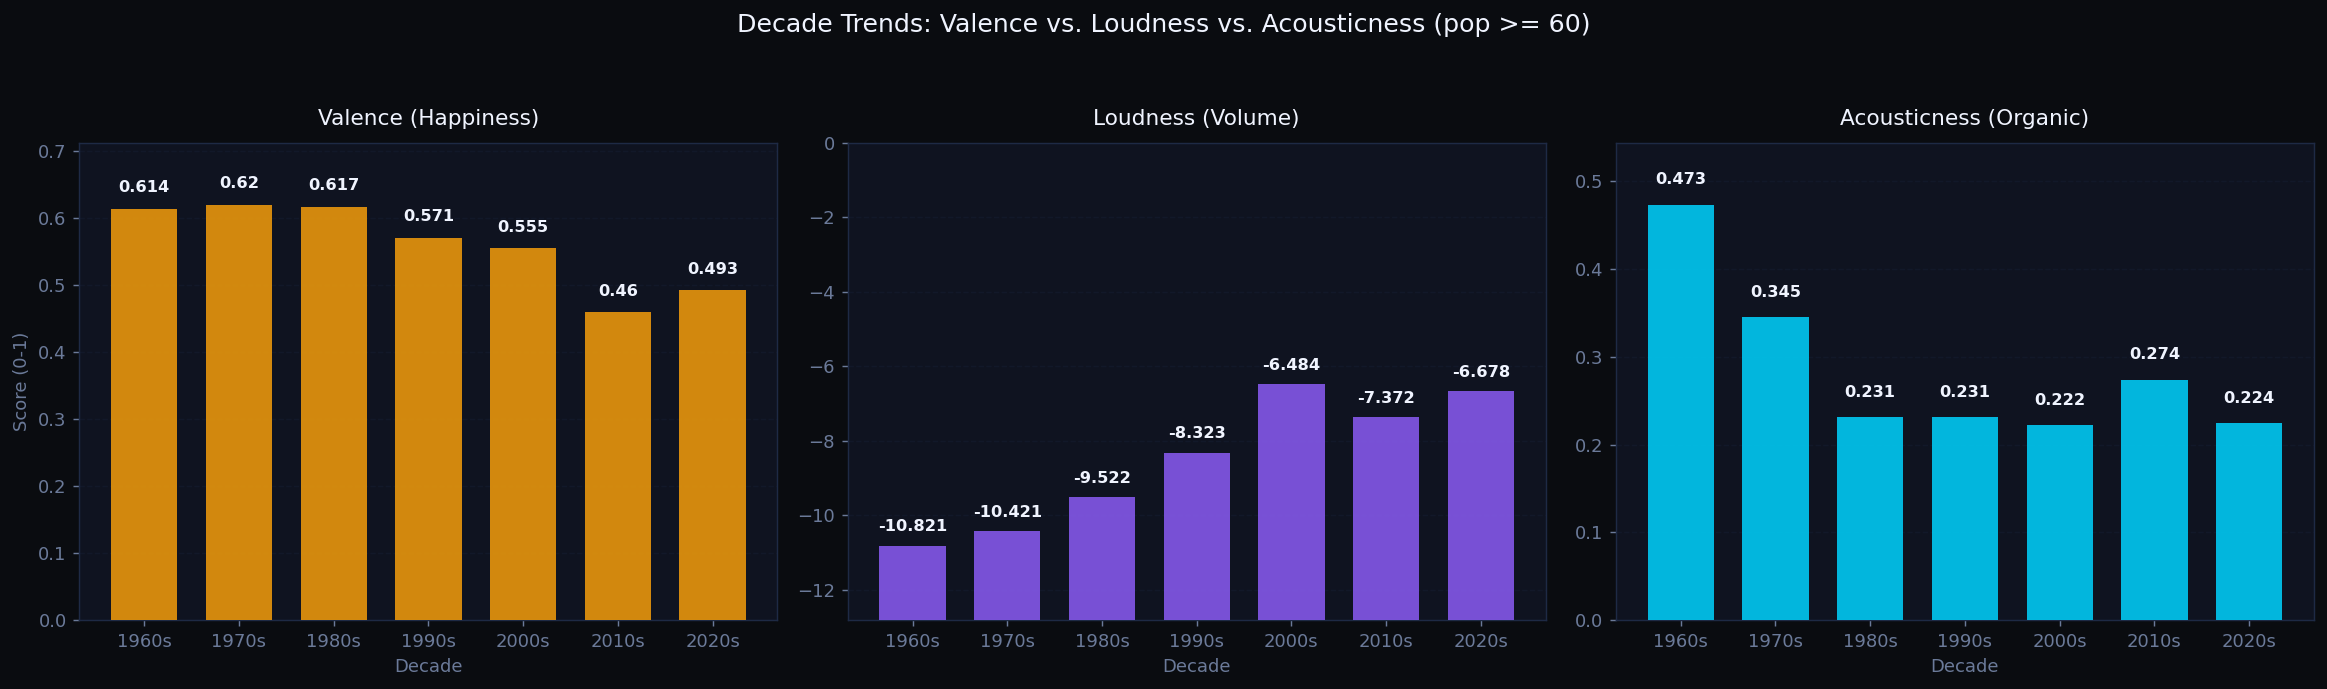

Saved: multimetric_comparison.png


In [39]:
# ── Multi-Metric Comparison Chart ─────────────────────────────────────────────
# Side-by-side bar charts for Valence, Loudness, and Acousticness (pop >= 60)

# 1. Prepare the data
stats = df_pop.groupby('decade')[['valence', 'loudness', 'acousticness']].mean().round(3)
decades = stats.index.astype(int).tolist()
labels  = [str(d)+'s' for d in decades]

# 2. Setup Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = [AMBER, PURPLE, CYAN]  # Distinct colors for each metric
titles = ['Valence (Happiness)', 'Loudness (Volume)', 'Acousticness (Organic)']
cols   = ['valence', 'loudness', 'acousticness']

# 3. Plot each metric
for i, ax in enumerate(axes):
    col = cols[i]
    vals = stats[col].values

    # Special handling for Loudness to make it look "upward" (staircase style)
    if col == 'loudness':
        floor = min(vals) - 2
        heights = vals - floor
        bars = ax.bar(labels, heights, bottom=floor, color=colors[i],
                      width=0.7, alpha=0.85, zorder=3)
        ax.set_ylim(floor, 0)
        ylabel = 'dB'
    else:
        # Standard 0-1 plots for Valence and Acousticness
        bars = ax.bar(labels, vals, color=colors[i],
                      width=0.7, alpha=0.85, zorder=3)
        ax.set_ylim(0, max(vals) * 1.15)
        ylabel = 'Score (0-1)'

    # Add value labels
    for bar, val in zip(bars, vals):
        y_pos = bar.get_height() + bar.get_y() if col == 'loudness' else val
        offset = 0.3 if col == 'loudness' else 0.02

        ax.text(bar.get_x() + bar.get_width()/2, y_pos + offset,
                f'{val}', ha='center', va='bottom',
                fontsize=9, color=WHITE, fontweight='bold')

    ax.set_title(titles[i], color=WHITE, fontsize=12, pad=10)
    ax.set_xlabel('Decade', fontsize=10)
    if i == 0: ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.25, zorder=0)

fig.suptitle(f'Decade Trends: Valence vs. Loudness vs. Acousticness (pop >= {THRESHOLD})',
             color=WHITE, fontsize=14, y=1.05)

plt.tight_layout()
plt.savefig('multimetric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: multimetric_comparison.png')